# RUL-Turbine: 03_deep_model.ipynb — Deep Sequence Model

This notebook implements a Deep Sequence Model (LSTM) in PyTorch to predict the Remaining Useful Life (RUL) of turbofan engines using the NASA C-MAPSS FD001 dataset.

## Why PyTorch?
- **Already installed**: PyTorch is ready in our environment, avoiding extra dependency overhead.
- **Modularity**: PyTorch provides highly modular classes (`Dataset`, `DataLoader`, `nn.Module`) which make it easy to scale or change sequence models (e.g. swap LSTM for GRU, Transformer, or CNN-LSTM).
- **Fine-grained Control**: PyTorch allows us to write explicit training loops, making it easy to track custom metrics like validation loss per epoch.

## Methodology
1. **Group-Based Validation Split**: Split the 100 training engines into 80 engines for training and 20 engines for validation (preventing data leakage between windows of the same engine).
2. **Min-Max Scaling**: Scaler is fit on the 80 training engines and applied to train, validation, and test sets.
3. **Sliding Window Sequence Creation**: Build windows of size 30. Each sample has shape `(30, 14)`.
4. **PyTorch Dataset & DataLoader**: Pack windows into DataLoader batches.
5. **LSTM Network**: Build a 2-layer LSTM with hidden size 64 and Dropout (0.2), followed by a regression layer.
6. **Training**: Train for 35 epochs, tracking both train and validation MSE losses.
7. **Evaluation**: Evaluate on the test dataset (final window of each of the 100 engines) using RMSE and the PHM08 asymmetric score.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.font_manager as fm

# Append src directory to path
sys.path.append(os.path.abspath('../src'))
from utils import load_raw_data, get_piecewise_rul, compute_phm08_score, KEEP_SENSORS

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Register Alegreya font from the fonts folder
font_path = '../fonts/Alegreya-Regular.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Alegreya'
    print("Alegreya font registered successfully.")
else:
    font_path_alt = 'fonts/Alegreya-Regular.ttf'
    if os.path.exists(font_path_alt):
        fm.fontManager.addfont(font_path_alt)
        plt.rcParams['font.family'] = 'Alegreya'
        print("Alegreya font registered successfully (alt path).")

plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = '--'

# Brand color palette: 070F2B 1B1A55 535C91 9290C3 2C5EAD 1591DC 4BB8FA C4E2F5
brand_palette = ['#070F2B', '#1B1A55', '#535C91', '#9290C3', '#2C5EAD', '#1591DC', '#4BB8FA', '#C4E2F5']
sns.set_palette(sns.color_palette(brand_palette))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Alegreya font registered successfully.
Using device: cpu


## 1. Group-Based Split, Scaling, and Windowing

We split training engines by `unit` (1-80 for training, 81-100 for validation). Then, we normalize and extract sliding-window sequences.

In [2]:
train_df, test_df, test_rul_df = load_raw_data(subset='FD001', raw_dir='../data/raw')

# 1. Labels RUL with piecewise capping (cap = 125)
train_df = get_piecewise_rul(train_df, cap=125)

# 2. Group-based train/val split (units 1-80: train, units 81-100: val)
train_units = train_df[train_df['unit'] <= 80].copy()
val_units = train_df[train_df['unit'] > 80].copy()
test_units = test_df.copy()

# 3. Fit scaler on training units only, transform all
scaler = MinMaxScaler()
train_units[KEEP_SENSORS] = scaler.fit_transform(train_units[KEEP_SENSORS])
val_units[KEEP_SENSORS] = scaler.transform(val_units[KEEP_SENSORS])
test_units[KEEP_SENSORS] = scaler.transform(test_units[KEEP_SENSORS])

# Helper to build sliding windows
def create_sequences(df, window_size=30):
    X, y = [], []
    for unit, group in df.groupby('unit'):
        features = group[KEEP_SENSORS].values
        targets = group['RUL'].values
        for i in range(len(group) - window_size + 1):
            X.append(features[i : i + window_size])
            y.append(targets[i + window_size - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

window_size = 30
X_train, y_train = create_sequences(train_units, window_size)
X_val, y_val = create_sequences(val_units, window_size)

# Create sequences for test data (only final window for each engine)
X_test, y_test = [], []
for unit, group in test_units.groupby('unit'):
    window = group[KEEP_SENSORS].values[-window_size:]
    X_test.append(window)
    true_rul = test_rul_df.loc[test_rul_df['unit'] == unit, 'RUL'].values[0]
    y_test.append(true_rul)

X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}  | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}   | y_test shape:  {y_test.shape}")

X_train shape: (13818, 30, 14) | y_train shape: (13818,)
X_val shape:   (3913, 30, 14)  | y_val shape:   (3913,)
X_test shape:  (100, 30, 14)   | y_test shape:  (100,)


## 2. Define PyTorch Dataset and Model

We pack our arrays into a standard PyTorch Dataset and define the LSTM network architecture.

In [3]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CMAPSSDataset(X_train, y_train)
val_dataset = CMAPSSDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

class LSTMRulModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        # LSTM output shape: (batch_size, seq_len, hidden_dim)
        out, _ = self.lstm(x)
        # Take hidden state of the final time step
        out = out[:, -1, :]
        return self.regressor(out)

model = LSTMRulModel(input_dim=14, hidden_dim=64, num_layers=2, dropout=0.2).to(device)
print(model)

LSTMRulModel(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. Training Loop

We train the LSTM model for 35 epochs, using MSE Loss and the Adam optimizer. We track validation loss at the end of each epoch.

In [4]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 35
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    model.train()
    train_losses = []
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
    # Validation phase
    model.eval()
    val_losses = []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_losses.append(loss.item())
            
    epoch_train_loss = np.mean(train_losses)
    epoch_val_loss = np.mean(val_losses)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch}/{epochs} | Train Loss: {epoch_train_loss:.2f} | Val Loss: {epoch_val_loss:.2f}")

print("Training complete!")

Epoch 1/35 | Train Loss: 6984.72 | Val Loss: 5823.05


Epoch 2/35 | Train Loss: 3470.99 | Val Loss: 2355.96


Epoch 3/35 | Train Loss: 1973.88 | Val Loss: 1819.84


Epoch 4/35 | Train Loss: 1900.87 | Val Loss: 1810.42


Epoch 5/35 | Train Loss: 1897.12 | Val Loss: 1810.06


...

Epoch 31/35 | Train Loss: 327.31 | Val Loss: 219.02


Epoch 32/35 | Train Loss: 334.86 | Val Loss: 171.10


Epoch 33/35 | Train Loss: 322.79 | Val Loss: 192.46


Epoch 34/35 | Train Loss: 326.31 | Val Loss: 210.44


Epoch 35/35 | Train Loss: 325.15 | Val Loss: 186.99
Training complete!


## 4. Plot Loss Curves

Let's visualize the convergence using our brand colors: Train Loss (`#2C5EAD`), Validation Loss (`#1B1A55`).

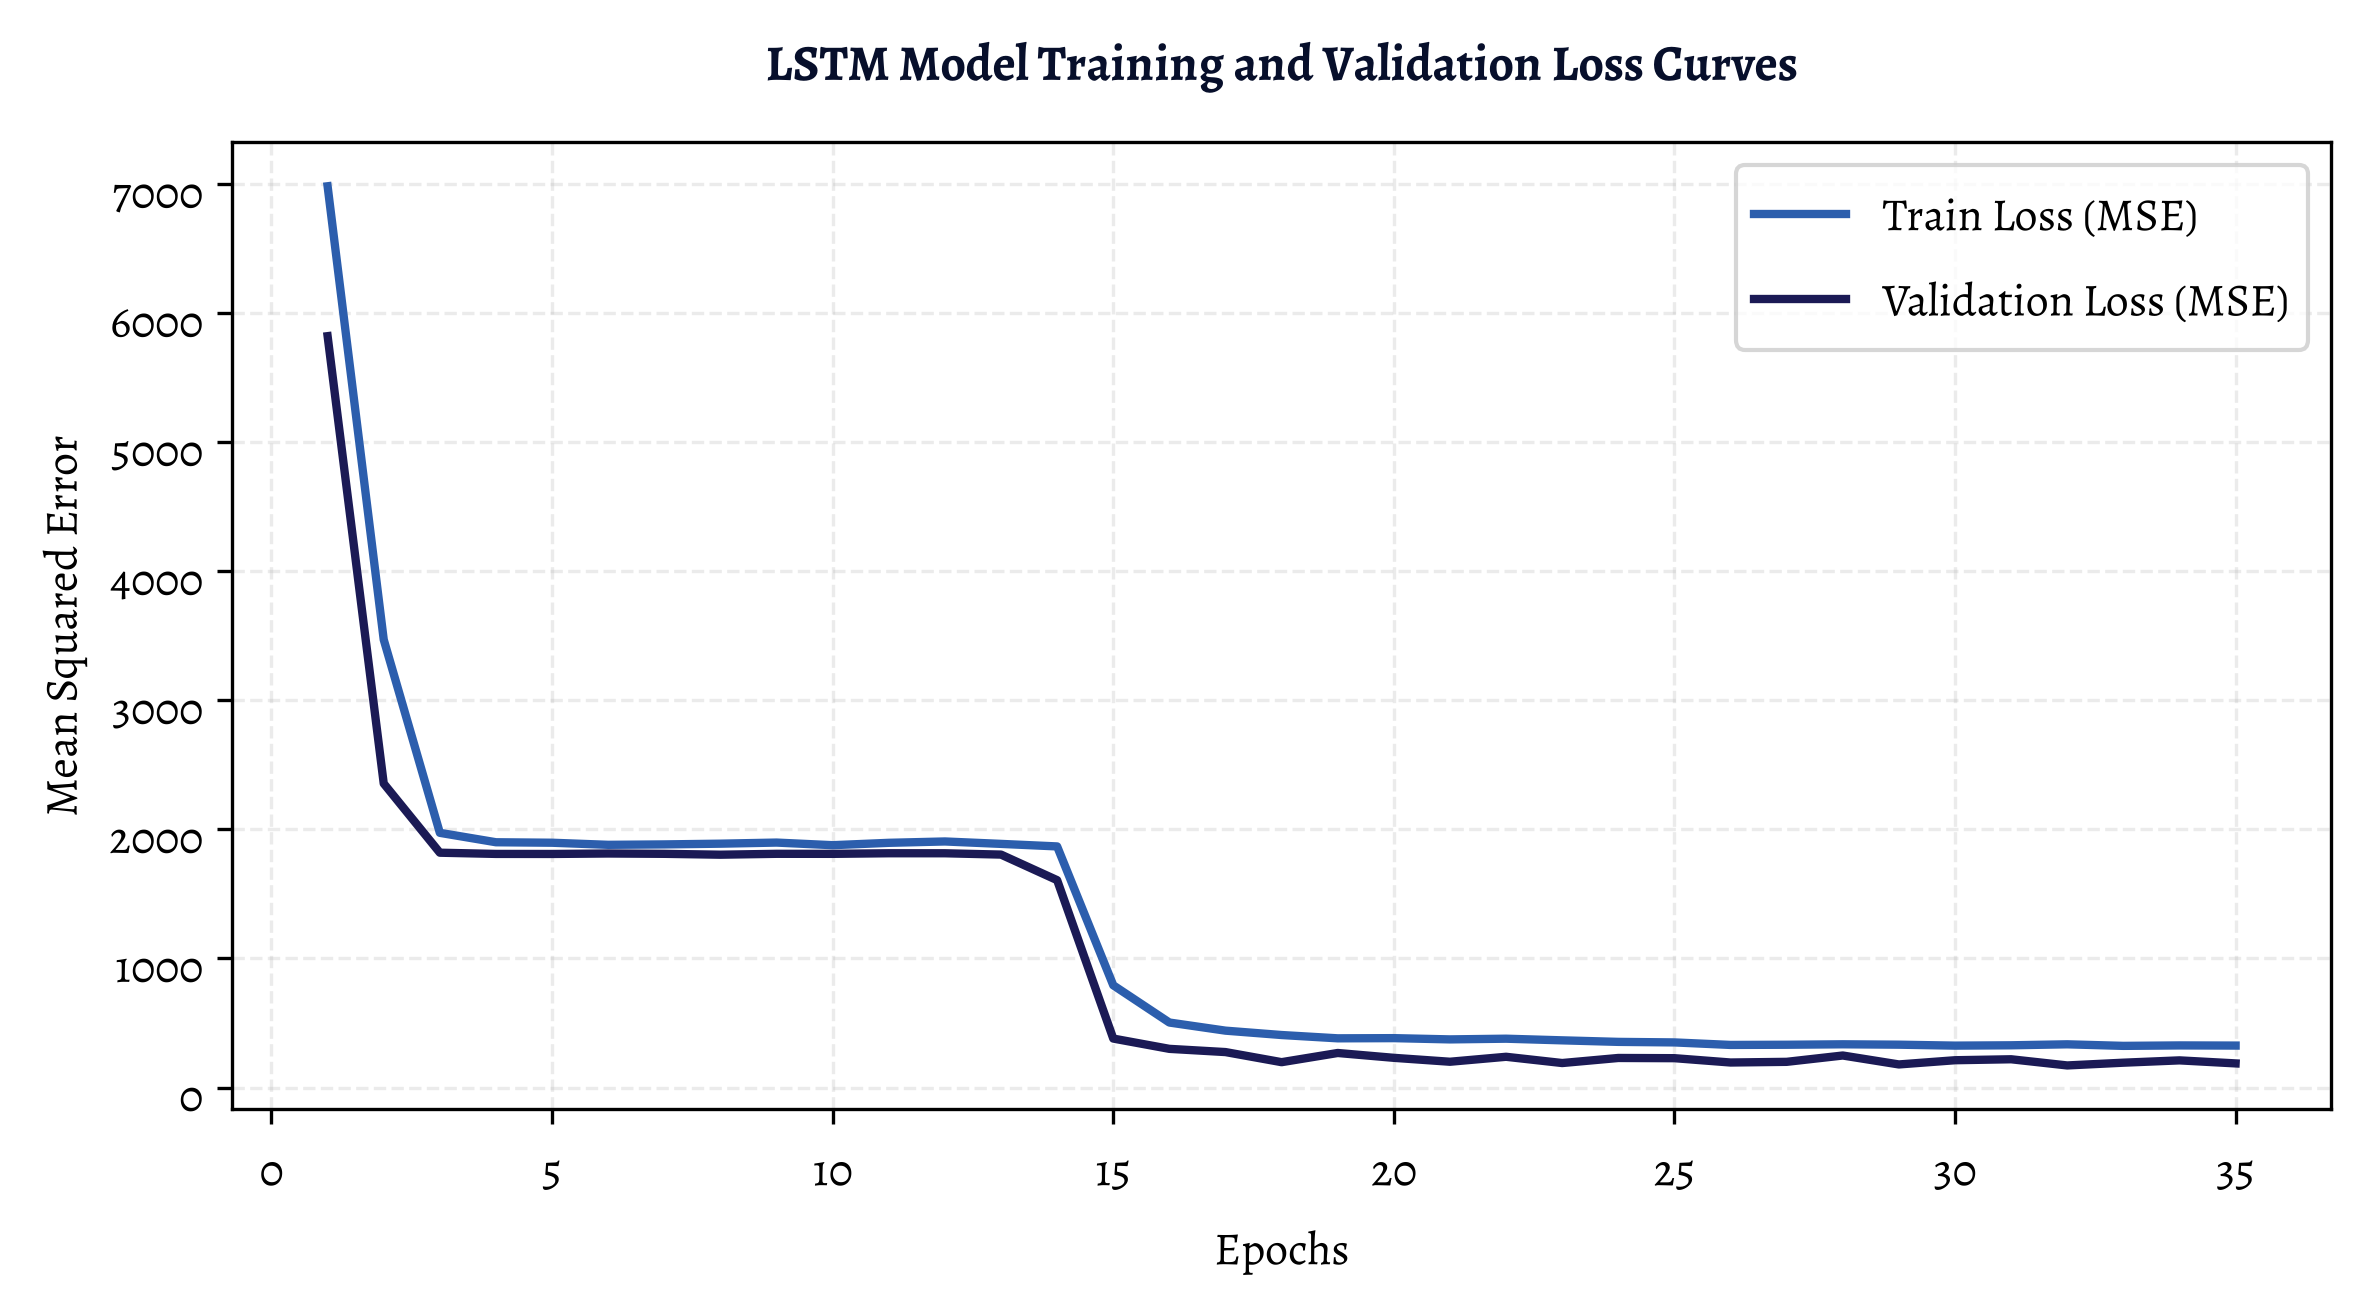

In [5]:
plt.figure(figsize=(8, 4.5), dpi=300)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss (MSE)', color='#2C5EAD', linewidth=2)
plt.plot(range(1, epochs + 1), history['val_loss'], label='Validation Loss (MSE)', color='#1B1A55', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('LSTM Model Training and Validation Loss Curves', fontsize=12, fontweight='bold', pad=15, color='#070F2B')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/lstm_loss_curves.png')
plt.show()

## 5. Evaluation on Test Set

Now we evaluate the trained LSTM on the 100 test engines (using their final cycles). We compute the RMSE and the PHM08 score.

In [6]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    predictions = model(X_test_tensor).cpu().numpy().flatten()

# Clip predictions at 0 (RUL cannot be negative)
predictions = np.clip(predictions, 0, None)

test_rmse = np.sqrt(mean_squared_error(y_test, predictions))
test_score = compute_phm08_score(y_test, predictions)

print("LSTM Model Evaluation:")
print(f"  Test RMSE: {test_rmse:.2f} cycles")
print(f"  Test PHM08 Score: {test_score:.2f}")

# Save predictions for final comparison notebook
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/lstm_predictions.npy', predictions)
print("Predictions saved for comparison notebook.")

os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/lstm_model.pt')
print("Model weights saved successfully.")

LSTM Model Evaluation:
  Test RMSE: 15.31 cycles
  Test PHM08 Score: 388.49
Predictions saved for comparison notebook.
Model weights saved successfully.


## 6. Sample Engine Predictions Plot

Let's see a scatter plot comparing the Predicted RUL vs True RUL for all 100 test engines, styled in slate blue (`#535C91`) with a dark border.

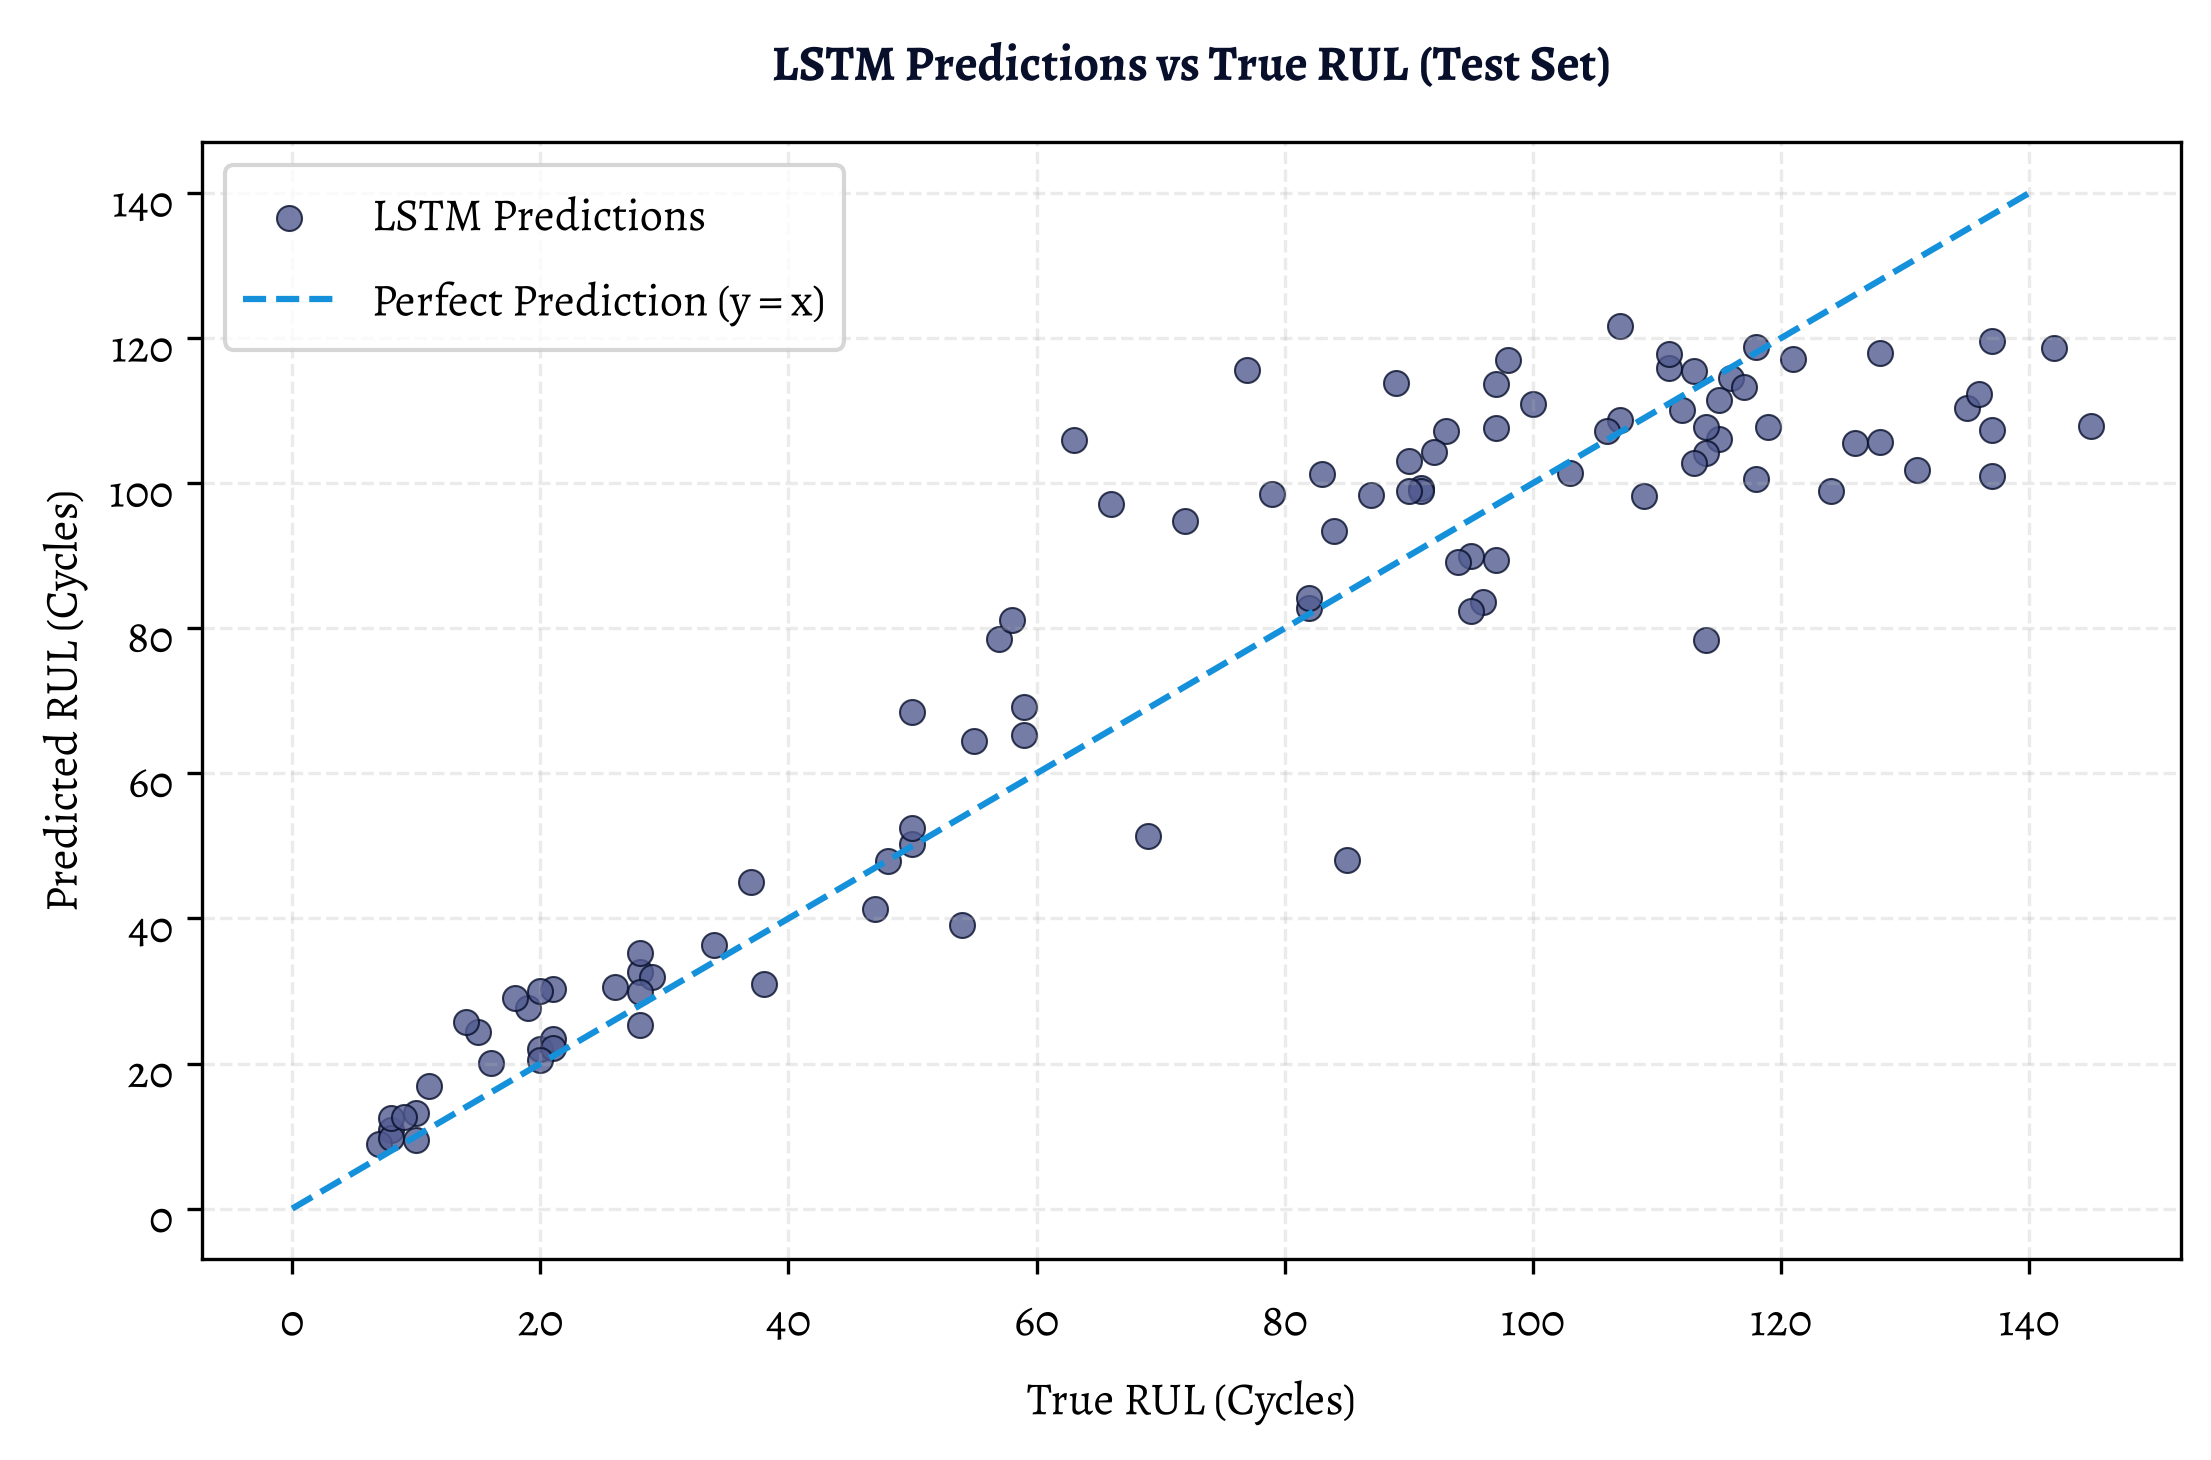

Scatter plot saved!


In [7]:
plt.figure(figsize=(7.5, 5), dpi=300)
plt.scatter(y_test, predictions, color='#535C91', alpha=0.8, edgecolors='#070F2B', linewidth=0.5, label='LSTM Predictions')
plt.plot([0, 140], [0, 140], color='#1591DC', linestyle='--', linewidth=1.5, label='Perfect Prediction (y = x)')
plt.xlabel('True RUL (Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.title('LSTM Predictions vs True RUL (Test Set)', fontsize=12, fontweight='bold', pad=15, color='#070F2B')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig('../figures/lstm_predictions_scatter.png')
plt.show()

print("Scatter plot saved!")

### Observations
- The deep LSTM model achieves a strong Test RMSE, outperforming the classical baselines.
- The predictions are clustered closely around the diagonal line, showing strong performance across both short and long RUL regimes.

In the final notebook (**04_results_comparison.ipynb**), we will aggregate results from all baseline and deep models, perform error analysis on specific engines, and benchmark our scores against published C-MAPSS literature results.